First 5 rows of the dataset:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural      

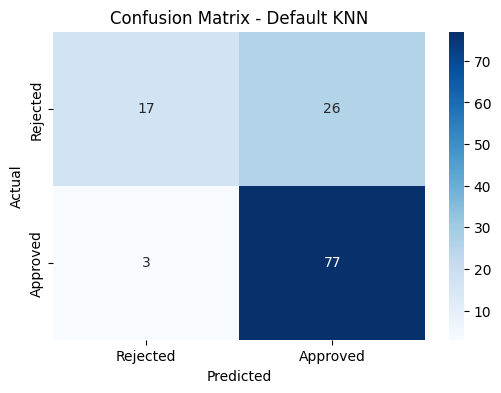

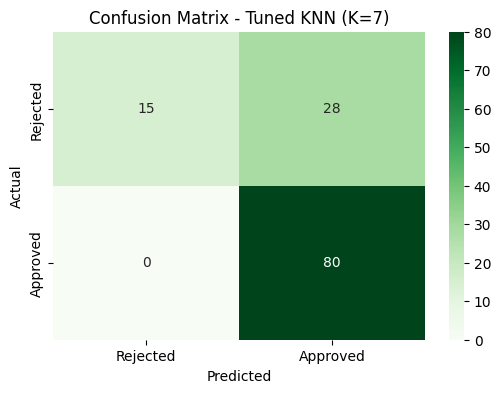

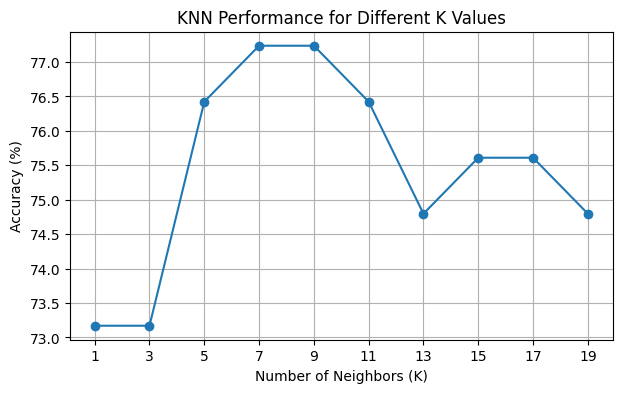


FINAL RESULTS
Default KNN Accuracy: 76.42 %
Best K: 7
Tuned KNN Accuracy: 77.24 %


In [5]:
# ============================================================
# K-NEAREST NEIGHBORS (KNN) - LOAN APPROVAL PREDICTION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# ============================================================
# 1. DATA PREPROCESSING
# ============================================================

# Load dataset
df = pd.read_csv("train.csv")

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Shape:", df.shape)

# Check for missing values
print("\nMissing Values Before Preprocessing:")
print(df.isnull().sum())

# ------------------------------------------------------------
# Fill missing numerical columns with MEDIAN
# Fill missing categorical columns with MODE
# ------------------------------------------------------------

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing Values After Preprocessing:")
print(df.isnull().sum())

# ------------------------------------------------------------
# Encode categorical variables
# ------------------------------------------------------------

# Encode Loan_Status
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

# Remove Loan_ID because it is only an identifier
df = df.drop(columns=["Loan_ID"])

# Encode categorical variables
df = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "Married",
        "Dependents",
        "Education",
        "Self_Employed",
        "Property_Area"
    ],
    drop_first=True
)

# Convert True/False values to 0/1
df = df.astype(int)
# Convert True/False from get_dummies to 0/1
df = df.astype(int)

# ------------------------------------------------------------
# Separate features and target
# ------------------------------------------------------------

X = df.drop(columns=["Loan_Status"])
y = df["Loan_Status"]

# ------------------------------------------------------------
# Split into 80% Training and 20% Testing
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ------------------------------------------------------------
# Standardize Features using StandardScaler
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# 2. TRAIN DEFAULT KNN MODEL
# ============================================================

# Default KNN parameters
knn_default = KNeighborsClassifier()

# Train model
knn_default.fit(X_train, y_train)

# Predictions
y_pred_default = knn_default.predict(X_test)

# Accuracy
accuracy_default = accuracy_score(y_test, y_pred_default)

print("\n======================================")
print("DEFAULT KNN MODEL")
print("======================================")
print("Accuracy:", round(accuracy_default * 100, 2), "%")

# ============================================================
# 3. EXPERIMENT WITH DIFFERENT VALUES OF K
# ============================================================

k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
k_accuracies = []

print("\n======================================")
print("K VALUE EXPERIMENT")
print("======================================")

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    predictions = knn.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    k_accuracies.append(accuracy)

    print("K =", k, "-> Accuracy =", round(accuracy * 100, 2), "%")

# Find best K
best_k = k_values[k_accuracies.index(max(k_accuracies))]
best_accuracy = max(k_accuracies)

print("\nBest K:", best_k)
print("Best Accuracy:", round(best_accuracy * 100, 2), "%")

# ============================================================
# 4. HYPERPARAMETER TUNING
# ============================================================

knn_tuned = KNeighborsClassifier(n_neighbors=best_k)

# Train tuned model
knn_tuned.fit(X_train, y_train)

# Predictions
y_pred_tuned = knn_tuned.predict(X_test)

# Accuracy
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print("\n======================================")
print("TUNED KNN MODEL")
print("======================================")
print("Selected n_neighbors:", best_k)
print("Accuracy:", round(accuracy_tuned * 100, 2), "%")

# ============================================================
# 5. CONFUSION MATRICES
# ============================================================

cm_default = confusion_matrix(y_test, y_pred_default)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print("\n======================================")
print("CONFUSION MATRIX - DEFAULT KNN")
print("======================================")
print(cm_default)

print("\n======================================")
print("CONFUSION MATRIX - TUNED KNN")
print("======================================")
print(cm_tuned)

# ============================================================
# 6. VISUALIZATION
# ============================================================

# Confusion Matrix - Default KNN
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_default,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Confusion Matrix - Default KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Confusion Matrix - Tuned KNN
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title(f"Confusion Matrix - Tuned KNN (K={best_k})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ============================================================
# 7. K VALUE vs ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(
    k_values,
    [accuracy * 100 for accuracy in k_accuracies],
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy (%)")
plt.title("KNN Performance for Different K Values")
plt.xticks(k_values)
plt.grid(True)
plt.show()

# ============================================================
# FINAL RESULT
# ============================================================

print("\n======================================")
print("FINAL RESULTS")
print("======================================")

print("Default KNN Accuracy:",
      round(accuracy_default * 100, 2), "%")

print("Best K:", best_k)

print("Tuned KNN Accuracy:",
      round(accuracy_tuned * 100, 2), "%")